In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# Load dataset
df = pd.read_csv('marketing_sales_data.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (572, 5)


       TV      Radio  Social Media Influencer       Sales
0     Low   3.518070      2.293790      Micro   55.261284
1     Low   7.756876      2.572287       Mega   67.574904
2    High  20.348988      1.227180      Micro  272.250108
3  Medium  20.108487      2.728374       Mega  195.102176
4    High  31.653200      7.776978       Nano  273.960377

In [11]:
# Check shape, missing values, data types
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Descriptive Statistics ===")
print(df.describe())

print("\n=== Categorical Column Values ===")
print("TV unique values:", df['TV'].unique())
print("Influencer unique values:", df['Influencer'].unique())

=== Data Types ===
TV               object
Radio           float64
Social Media    float64
Influencer       object
Sales           float64
dtype: object

=== Missing Values ===
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

=== Descriptive Statistics ===
            Radio  Social Media       Sales
count  572.000000    572.000000  572.000000
mean    17.520616      3.333803  189.296908
std      9.290933      2.238378   89.871581
min      0.109106      0.000031   33.509810
25%     10.699556      1.585549  118.718722
50%     17.149517      3.150111  184.005362
75%     24.606396      4.730408  264.500118
max     42.271579     11.403625  357.788195

=== Categorical Column Values ===
TV unique values: ['Low' 'High' 'Medium']
Influencer unique values: ['Micro' 'Mega' 'Nano' 'Macro']


In [12]:
# Encode TV and Influencer as dummy variables (drop_first avoids multicollinearity trap)
df_encoded = pd.get_dummies(df, columns=['TV', 'Influencer'], drop_first=True)

# Rename Social Media column to remove space
df_encoded = df_encoded.rename(columns={'Social Media': 'Social_Media'})

print("=== Encoded Columns ===")
print(df_encoded.columns.tolist())

print("\n=== First 5 Rows ===")
print(df_encoded.head())

print(f"\nShape: {df_encoded.shape}")

=== Encoded Columns ===
['Radio', 'Social_Media', 'Sales', 'TV_Low', 'TV_Medium', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']

=== First 5 Rows ===
       Radio  Social_Media       Sales  TV_Low  TV_Medium  Influencer_Mega  \
0   3.518070      2.293790   55.261284    True      False            False   
1   7.756876      2.572287   67.574904    True      False             True   
2  20.348988      1.227180  272.250108   False      False            False   
3  20.108487      2.728374  195.102176   False       True             True   
4  31.653200      7.776978  273.960377   False      False            False   

   Influencer_Micro  Influencer_Nano  
0              True            False  
1             False            False  
2              True            False  
3             False            False  
4             False             True  

Shape: (572, 8)


=== Correlation with Sales ===
Radio               0.858036
Social_Media        0.542048
TV_Medium           0.050449
Influencer_Mega     0.032443
Influencer_Nano     0.017656
Influencer_Micro   -0.006503
TV_Low             -0.805896
Name: Sales, dtype: float64


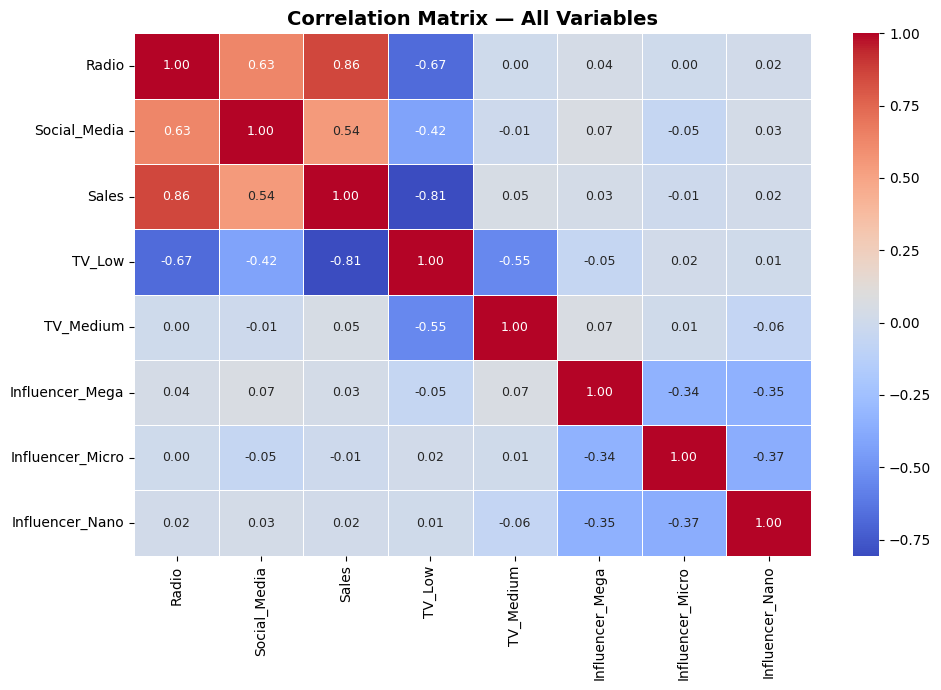

In [13]:
# Convert booleans to integers for correlation
df_encoded = df_encoded.astype({
    'TV_Low': int, 'TV_Medium': int,
    'Influencer_Mega': int, 'Influencer_Micro': int, 'Influencer_Nano': int
})

# Correlation matrix
corr_matrix = df_encoded.corr()

print("=== Correlation with Sales ===")
print(corr_matrix['Sales'].drop('Sales').sort_values(ascending=False))

# Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix — All Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Define predictor variables
X_cols = ['Radio', 'Social_Media', 'TV_Low', 'TV_Medium',
          'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']

X_vif = df_encoded[X_cols]

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_cols
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

print("=== Variance Inflation Factor (VIF) ===")
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))
print("\nRule: VIF > 10 = severe multicollinearity")
print("      VIF > 5  = moderate multicollinearity")

=== Variance Inflation Factor (VIF) ===
         Feature      VIF
           Radio 6.695980
    Social_Media 5.344600
 Influencer_Nano 2.084801
Influencer_Micro 2.083851
 Influencer_Mega 1.996014
       TV_Medium 1.664554
          TV_Low 1.661129

Rule: VIF > 10 = severe multicollinearity
      VIF > 5  = moderate multicollinearity


## Multicollinearity Check – Findings

### Correlation Matrix Observations
- Radio has the strongest positive correlation with Sales (r = 0.86)
- TV_Low has a strong negative correlation with Sales (r = -0.81),
  meaning low TV spend is strongly associated with lower sales
- Social_Media shows moderate positive correlation (r = 0.54)
- Influencer dummies show weak correlation with Sales (< 0.05)

### VIF Results
| Feature         | VIF    | Interpretation         |
|-----------------|--------|------------------------|
| Radio           | 6.70   | Moderate — acceptable  |
| Social_Media    | 5.34   | Moderate — acceptable  |
| Influencer_Nano | 2.08   | Low — no concern       |
| Influencer_Micro| 2.08   | Low — no concern       |
| Influencer_Mega | 2.00   | Low — no concern       |
| TV_Medium       | 1.66   | Low — no concern       |
| TV_Low          | 1.66   | Low — no concern       |

### Conclusion
No severe multicollinearity detected (all VIF < 10). Radio and
Social_Media show moderate VIF values but remain within acceptable
range. All predictors will be retained in the model.

In [15]:
# Define X and y
X = df_encoded[['Radio', 'Social_Media', 'TV_Low', 'TV_Medium',
                'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']]
y = df_encoded['Sales']

# Add constant
X_ols = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X_ols).fit()

# Display summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Sun, 14 Jun 2026   Prob (F-statistic):          1.82e-282
Time:                        17:45:45   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              217.4784      6.584  

## Multiple Linear Regression – Model Results & Interpretation

### Model Equation
Sales = 217.48 + 2.97(Radio) - 0.14(Social_Media)
        - 154.57(TV_Low) - 75.59(TV_Medium)
        + 2.49(Influencer_Mega) + 2.94(Influencer_Micro)
        + 0.80(Influencer_Nano)

### Model Performance
| Metric            | Value  | Interpretation                          |
|-------------------|--------|-----------------------------------------|
| R-squared         | 0.904  | Model explains 90.4% of Sales variance  |
| Adj. R-squared    | 0.903  | Adjusted for 7 predictors — still strong|
| F-statistic       | 760.4  | Overall model is highly significant     |
| Prob(F-statistic) | 0.000  | Model is statistically valid            |

### Coefficient Interpretation (holding all others constant)

**Statistically Significant Predictors (p < 0.05):**

- **const (217.48):** Baseline Sales for a High TV, Macro Influencer
  campaign with zero Radio and Social Media spend is $217,480.

- **Radio (2.97, p = 0.000):** Each additional $1K in Radio spend
  increases Sales by $2,974 — the strongest positive driver.

- **TV_Low (-154.57, p = 0.000):** Compared to High TV spend,
  a Low TV budget reduces Sales by $154,574 on average.

- **TV_Medium (-75.59, p = 0.000):** Compared to High TV spend,
  a Medium TV budget reduces Sales by $75,594 on average.

**Not Statistically Significant (p > 0.05):**

- **Social_Media (-0.14, p = 0.837):** No significant impact on
  Sales when other channels are held constant. Excluded from
  final recommendations.

- **Influencer_Mega (p = 0.471), Influencer_Micro (p = 0.385),
  Influencer_Nano (p = 0.811):** Influencer type has no
  statistically significant effect on Sales.

### Key Insight
TV spend level and Radio budget are the two most impactful
drivers of Sales. Social Media and Influencer type do not
contribute meaningfully once TV and Radio are accounted for.

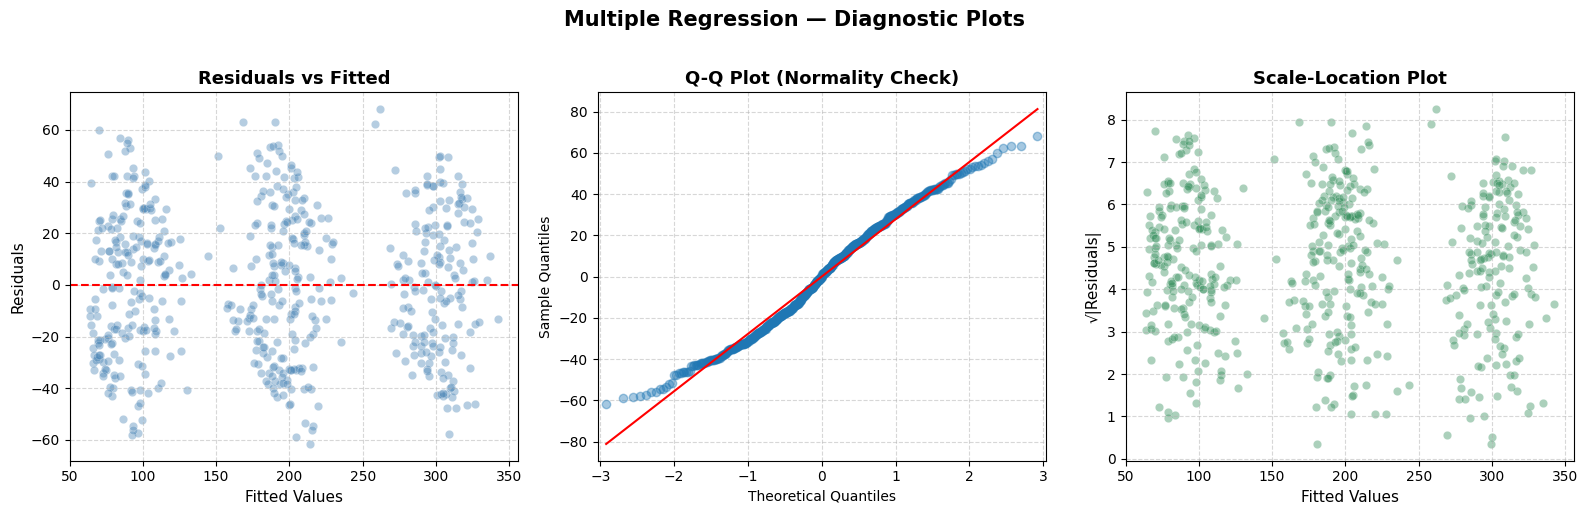

In [16]:
fitted = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Residuals vs Fitted
axes[0].scatter(fitted, residuals, alpha=0.4, color='steelblue',
                edgecolors='white', linewidth=0.3)
axes[0].axhline(y=0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title('Residuals vs Fitted', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fitted Values', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Q-Q Plot
sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.4)
axes[1].set_title('Q-Q Plot (Normality Check)', fontsize=13, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. Scale-Location
axes[2].scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.4,
                color='seagreen', edgecolors='white', linewidth=0.3)
axes[2].set_title('Scale-Location Plot', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Fitted Values', fontsize=11)
axes[2].set_ylabel('√|Residuals|', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Multiple Regression — Diagnostic Plots',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Diagnostic Plots – Assumption Validation

### 1. Residuals vs Fitted (Linearity & Homoscedasticity)
Residuals are roughly scattered around the zero line across all
fitted values with no strong systematic pattern. However, there is
slightly more spread in the middle range (100–250), suggesting mild
heteroscedasticity. Overall the linearity assumption is reasonably
satisfied.

### 2. Q-Q Plot (Normality)
Residuals follow the diagonal line closely in the middle range,
confirming approximate normality for most observations. The tails
deviate slightly, indicating some heavy-tail behaviour. This is
consistent with the Omnibus test (p = 0.000) and Jarque-Bera
(p = 0.000136) from the model summary, suggesting mild non-normality
at the extremes. With 572 observations, the model remains robust
due to the Central Limit Theorem.

### 3. Scale-Location Plot (Homoscedasticity)
The spread of residuals is relatively consistent across fitted
values with no clear funnel or cone shape, supporting the
homoscedasticity assumption. Some clustering is visible around
lower fitted values (50–100) which corresponds to the Low TV
spend group behaving differently from other groups.

### Overall Assessment
✓ Linearity: reasonably satisfied
⚠ Normality: approximately satisfied; mild tail deviation noted
✓ Homoscedasticity: largely satisfied
The model is sufficiently valid for business interpretation and
decision-making despite minor assumption violations.

## Final Report – Multi-Channel Marketing ROI Recommendation

### Model Summary
A Multiple Linear Regression model was built using TV spend level,
Radio budget, Social Media budget, and Influencer type to predict
Sales across 572 observations.

    Sales = 217.48 + 2.97(Radio) - 154.57(TV_Low) - 75.59(TV_Medium)

Adj. R-squared = 0.903 — the model explains 90.3% of Sales variance.

### Significant Predictors
| Predictor    | Coefficient | p-value | Business Meaning                       |
|--------------|-------------|---------|----------------------------------------|
| Radio        | +2.97       | 0.000   | +$2,974 sales per $1K Radio spend      |
| TV_Low       | -154.57     | 0.000   | -$154,574 vs High TV spend             |
| TV_Medium    | -75.59      | 0.000   | -$75,594 vs High TV spend              |
| Social_Media | -0.14       | 0.837   | Not significant — no measurable impact |
| Influencer   | varies      | > 0.05  | Not significant — no measurable impact |

### Recommendations

1. **Maximise TV spend at HIGH level.** The difference between High
   and Low TV is $154,574 in Sales — the single biggest lever in
   the model. Never operate at Low TV budget if sales growth is
   the goal.

2. **Increase Radio budget.** Every additional $1,000 in Radio
   spend generates $2,974 in Sales while holding other channels
   constant. This is the strongest continuous positive driver.

3. **Deprioritise Social Media.** With a p-value of 0.837, Social
   Media spend has no statistically significant effect on Sales
   when TV and Radio are already accounted for. Budget here should
   be minimised or reallocated.

4. **Influencer type does not matter.** None of the four Influencer
   categories (Mega, Micro, Nano, Macro) produced a significant
   effect on Sales. Selection should be based on cost efficiency
   rather than expected sales impact.

### Conclusion
The evidence clearly supports a budget strategy centred on High TV
spend and strong Radio investment. Social Media and Influencer
partnerships, while potentially valuable for brand awareness, do
not demonstrably drive Sales in this dataset.